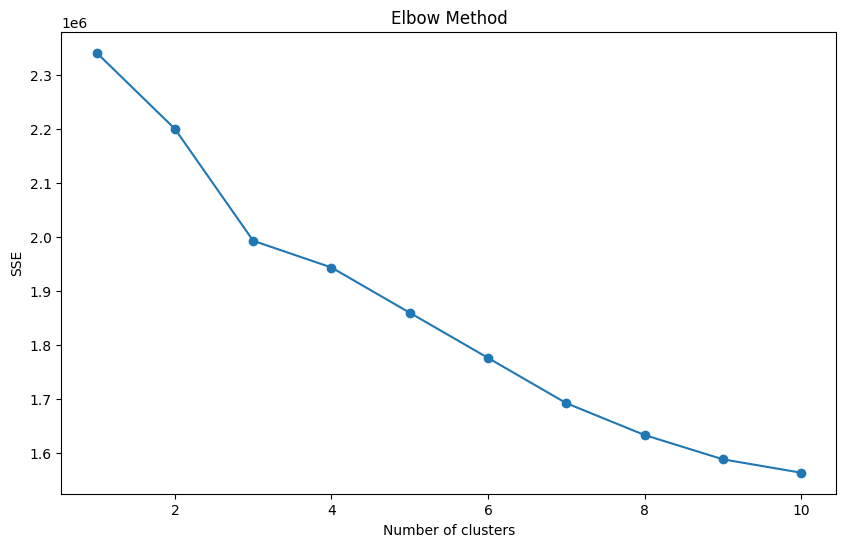

In [162]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
import pandas as pd
# Suppress the SettingWithCopyWarning
pd.options.mode.chained_assignment = None
pd.set_option('display.max_columns', None)
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
data = pd.read_csv('HotelCustomersDataset.csv', sep='\t')

data['TotalRevenue'] = data['LodgingRevenue'] + data['OtherRevenue']

# Initialize LabelEncoder
label_encoder = LabelEncoder() # Fit and transform the Nationality column
data['NationalityNumeric'] = label_encoder.fit_transform(data['Nationality'])
data['DistributionChannelNumeric'] = label_encoder.fit_transform(data['DistributionChannel'])
data['MarketSegmentNumeric'] = label_encoder.fit_transform(data['MarketSegment'])

#print(data.columns)

# Create the mapping dictionaries
mappingNationality = dict(zip(data['NationalityNumeric'], data['Nationality']))
mappingDistributionChannel = dict(zip(data['DistributionChannelNumeric'], data['DistributionChannel']))
mappingMarketSegment = dict(zip(data['MarketSegmentNumeric'], data['MarketSegment']))


data['Age'].fillna(data['Age'].mean(), inplace=True)
#Convert the 'Age' column from float to integer
data['Age'] = data['Age'].astype(int)

data.drop(columns=['ID','NameHash', 'DocIDHash','Nationality','DistributionChannel','MarketSegment','TotalRevenue'], inplace=True)
#data.drop(columns=['ID','NameHash', 'DocIDHash','Nationality','DistributionChannel','MarketSegment','LodgingRevenue','OtherRevenue'], inplace=True)

scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

sse = []
for k in range(1, 11):
  kmeans = KMeans(n_clusters=k, random_state=42)
  kmeans.fit(data_scaled)
  sse.append(kmeans.inertia_)
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), sse, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('SSE')
plt.title('Elbow Method')
plt.show()



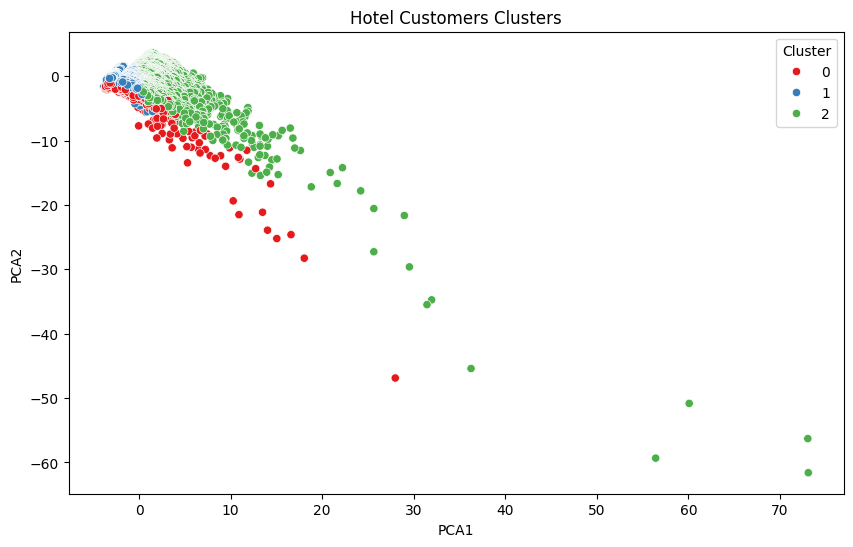

In [163]:
# Assume the optimal number of clusters from the Elbow Method is 3
optimal_clusters = 3
kmeans = KMeans(n_clusters=optimal_clusters, random_state=42)
data['Cluster'] = kmeans.fit_predict(data_scaled)
# Use PCA for dimensionality reduction to visualize clusters
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
data_pca = pca.fit_transform(data_scaled)
data_pca = pd.DataFrame(data_pca, columns=['PCA1', 'PCA2'])
data_pca['Cluster'] = data['Cluster']

plt.figure(figsize=(10, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=data_pca, palette='Set1')
plt.title('Hotel Customers Clusters')
plt.show()


In [164]:
# Interpret clusters
cluster_centers = pd.DataFrame(kmeans.cluster_centers_, columns=data.columns[:-1])
print("Cluster Centers:")
print(cluster_centers)

# Group by cluster to see the characteristics
cluster_profiles = data.groupby('Cluster').mean()
print("\nCluster Profiles:")
print(cluster_profiles)

Cluster Centers:
        Age  DaysSinceCreation  AverageLeadTime  LodgingRevenue  OtherRevenue  \
0 -0.132781          -0.139531        -0.325395       -0.099687     -0.137317   
1 -0.193268          -0.788113        -0.417262       -0.463969     -0.418489   
2  0.181603           0.602648         0.405362        0.360803      0.341699   

   BookingsCanceled  BookingsNoShowed  BookingsCheckedIn  PersonsNights  \
0          0.095864          0.072759           0.041489      -0.242064   
1         -0.028196         -0.021460          -0.519462      -0.640413   
2         -0.013042         -0.009856           0.351431       0.533856   

   RoomNights  DaysSinceLastStay  DaysSinceFirstStay  SRHighFloor  SRLowFloor  \
0   -0.179343          -0.160181           -0.141600    -0.044377    0.021336   
1   -0.604484          -0.916692           -0.921156     0.037974   -0.009801   
2    0.487045           0.700244            0.697011    -0.011506   -0.000421   

   SRAccessibleRoom  SRMediumFlo

In [165]:
# Group by clusters and calculate cumulative and average revenue
revenue_stats = data.groupby('Cluster')['LodgingRevenue'].agg(['sum', 'mean']).reset_index()

# Rename columns for clarity
revenue_stats.columns = ['Cluster', 'Cumulative Revenue', 'Average Lodging Revenue per Customer']

# Display the revenue statistics
print(revenue_stats)


   Cluster  Cumulative Revenue  Average Lodging Revenue per Customer
0        0          3667013.76                            261.686560
1        1          3582421.84                            124.992912
2        2         17727430.86                            433.264025


In [166]:
# Group by clusters and calculate cumulative and average revenue
revenue_stats = data.groupby('Cluster')['OtherRevenue'].agg(['sum', 'mean']).reset_index()

# Rename columns for clarity
revenue_stats.columns = ['Cluster', 'Cumulative Revenue', 'Average Other Revenue per Customer']

# Display the revenue statistics
print(revenue_stats)


   Cluster  Cumulative Revenue  Average Other Revenue per Customer
0        0           727195.49                           51.894347
1        1           561425.06                           19.588467
2        2          4361154.98                          106.588009


In [167]:
# Group by clusters and calculate age statistics
age_stats = data.groupby('Cluster')['Age'].agg(['mean', 'median', 'std']).reset_index()

# Rename columns for clarity
age_stats.columns = ['Cluster', 'Mean Age', 'Median Age', 'Age Standard Deviation']

# Display the age statistics
print(age_stats)


   Cluster   Mean Age  Median Age  Age Standard Deviation
0        0  43.230358        45.0               15.644436
1        1  42.226021        44.0               17.307637
2        2  48.325594        48.0               14.995498


In [173]:
# Group by clusters and calculate average room nights per user
average_room_nights = data.groupby('Cluster')['RoomNights'].mean().reset_index()

# Rename columns for clarity
average_room_nights.columns = ['Cluster', 'Average Room Nights per User']

# Display the average room nights per user for each cluster
print(average_room_nights)


   Cluster  Average Room Nights per User
0        0                      1.949547
1        1                      0.973204
2        2                      3.469010


               Age  DaysSinceCreation  AverageLeadTime  LodgingRevenue  \
Cluster                                                                  
0        43.230358         409.963605        37.644830      261.686560   
1        42.226021         206.552632        29.359024      124.992912   
2        48.325594         641.680956       101.778033      433.264025   

         OtherRevenue  BookingsCanceled  BookingsNoShowed  BookingsCheckedIn  \
Cluster                                                                        
0           51.894347          0.008421          0.002783           0.823521   
1           19.588467          0.000140          0.000000           0.431527   
2          106.588009          0.001149          0.000342           1.039056   

         PersonsNights  RoomNights  DaysSinceLastStay  DaysSinceFirstStay  \
Cluster                                                                     
0             3.544423    1.949547         345.516378          354.139371 

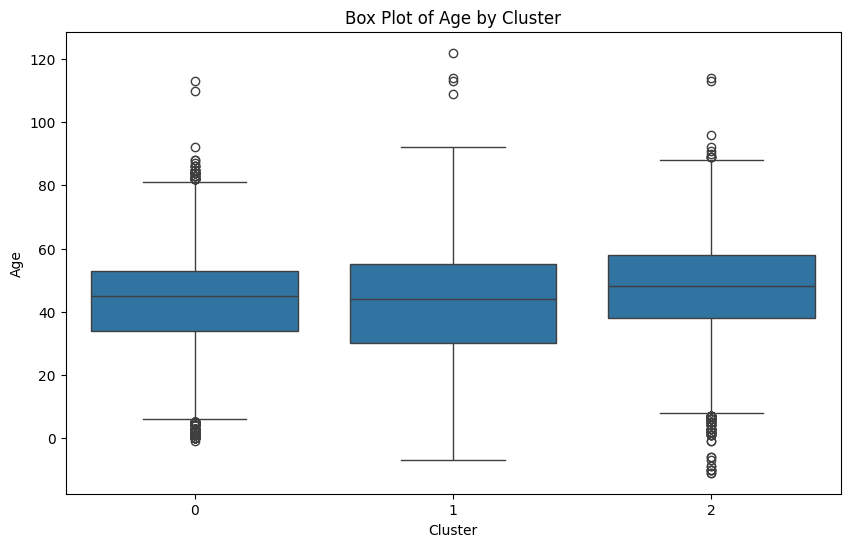

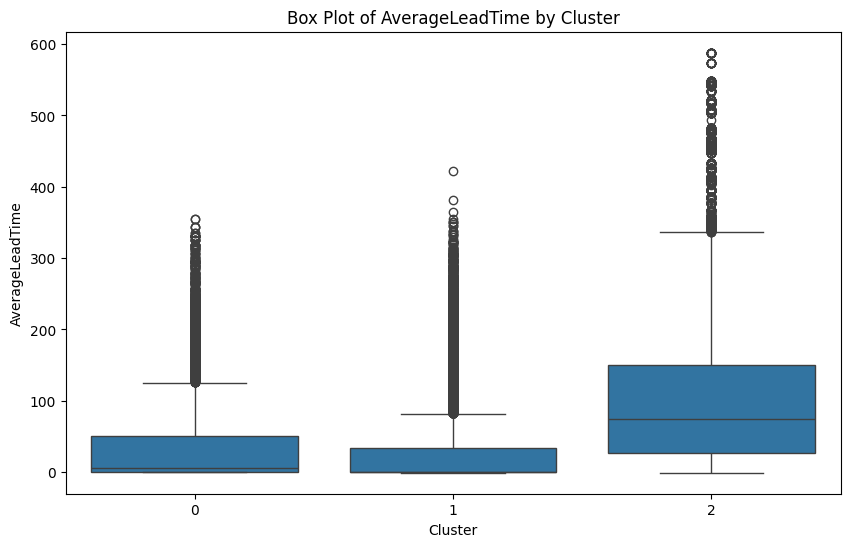

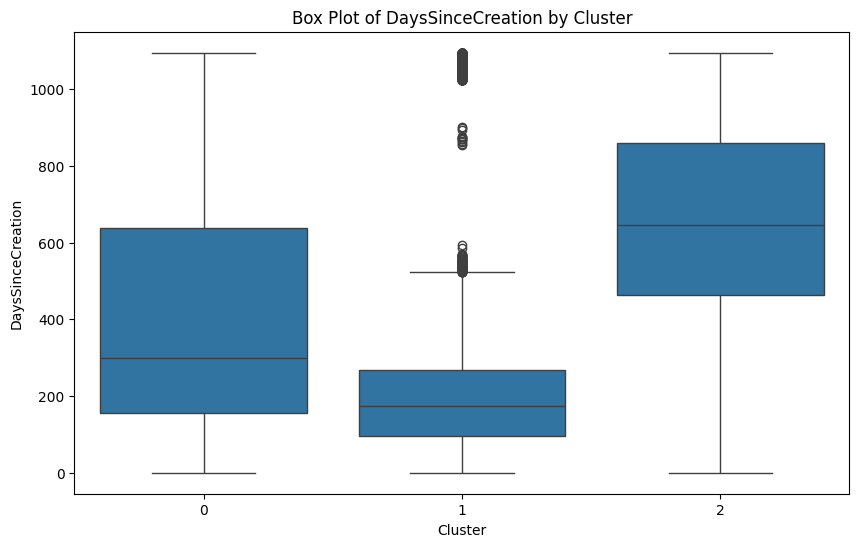

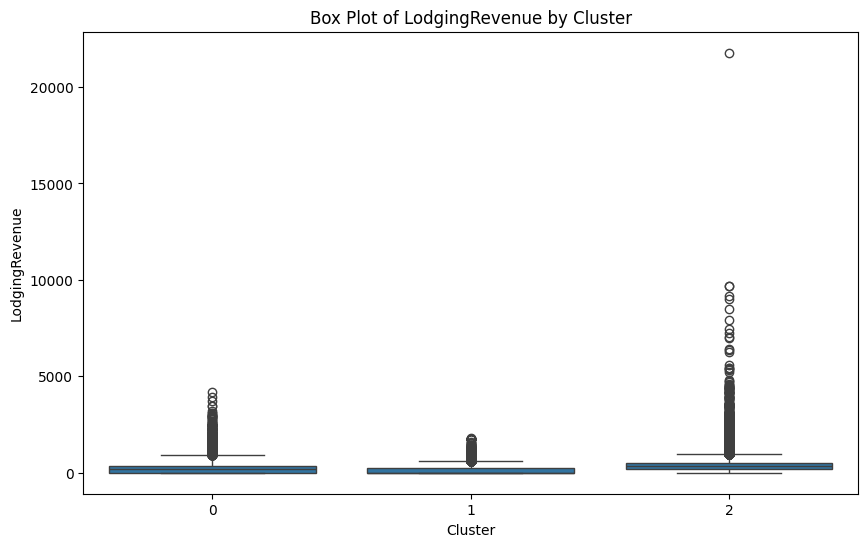

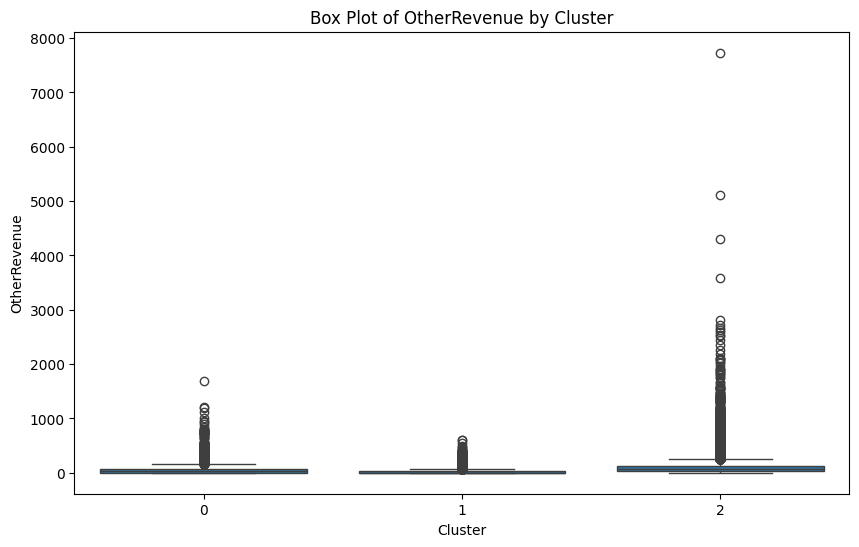

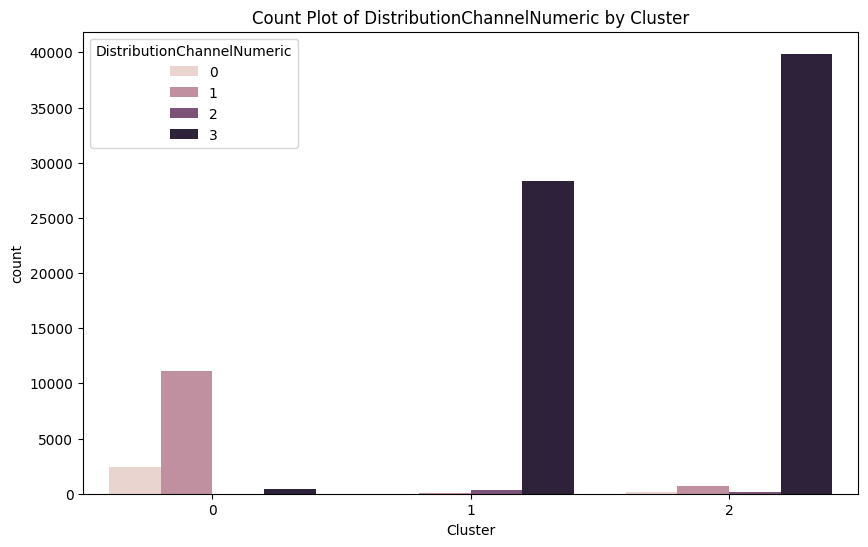

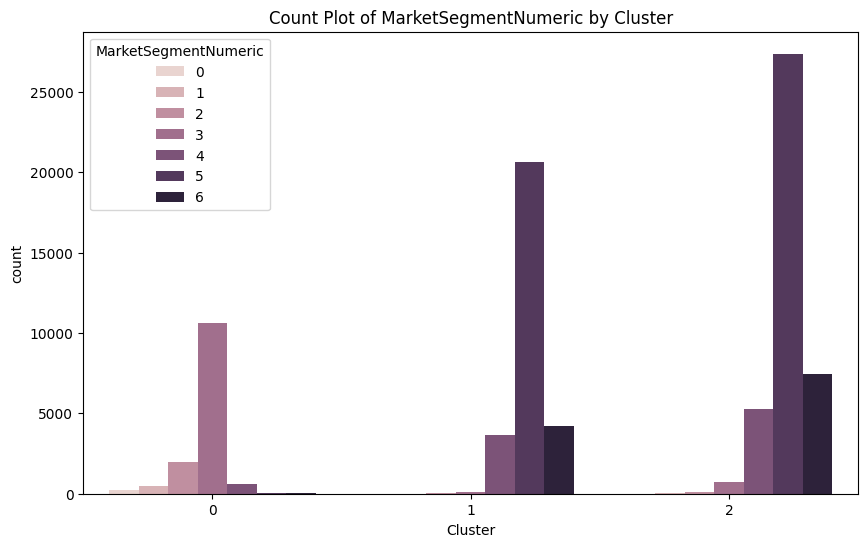

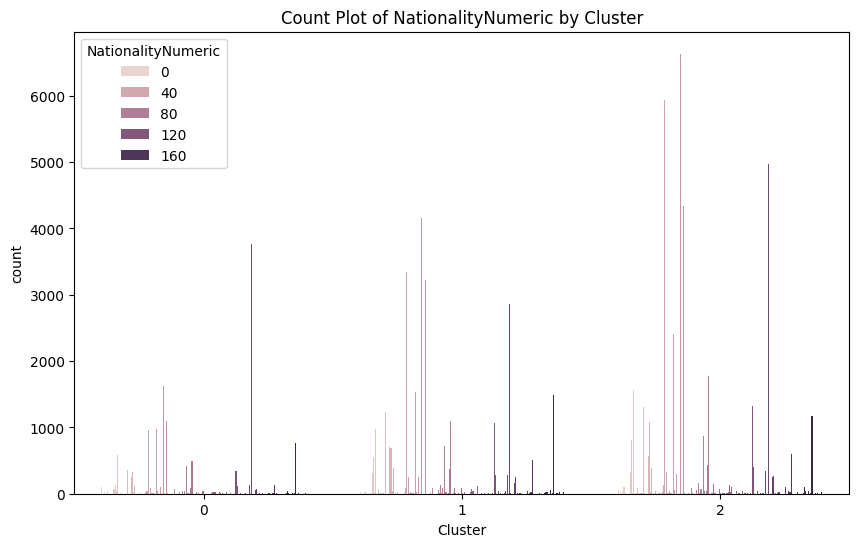

In [148]:
# Calculate descriptive statistics for each cluster
cluster_summary = data.groupby('Cluster').mean()
print(cluster_summary)
import matplotlib.pyplot as plt
import seaborn as sns

# Box plots for numerical features
numerical_features = ['Age', 'AverageLeadTime', 'DaysSinceCreation', 'LodgingRevenue','OtherRevenue']
for feature in numerical_features:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='Cluster', y=feature, data=data)
    plt.title(f'Box Plot of {feature} by Cluster')
    plt.show()

# Count plots for categorical features
categorical_features = ['DistributionChannelNumeric', 'MarketSegmentNumeric', 'NationalityNumeric']
for feature in categorical_features:
    plt.figure(figsize=(10, 6))
    sns.countplot(x='Cluster', hue=feature, data=data)
    plt.title(f'Count Plot of {feature} by Cluster')
    plt.show()


In [168]:
#Creating Mapping to help identify values from respective numeric values
data['Nationality'] = data['NationalityNumeric'].map(mappingNationality)
data['DistributionChannel'] = data['DistributionChannelNumeric'].map(mappingDistributionChannel)
data['MarketSegment'] = data['MarketSegmentNumeric'].map(mappingMarketSegment)


Top 5 Nationalities in Cluster 1:
Nationality
PRT    3764
FRA    1624
GBR    1098
ESP     969
DEU     958
Name: count, dtype: int64


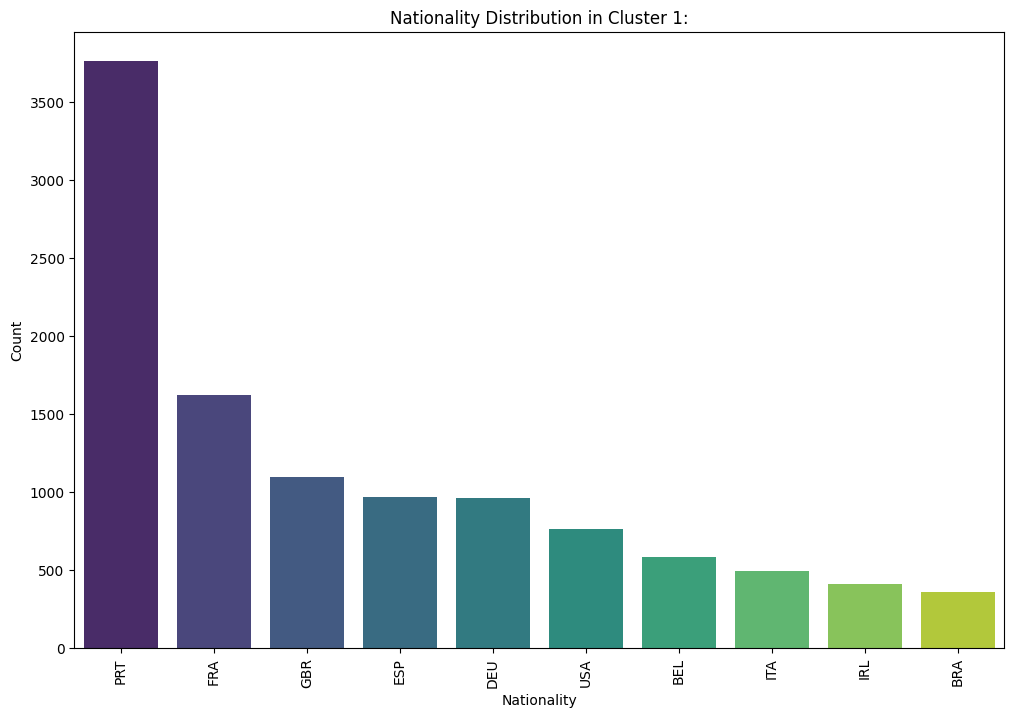

DistributionChannel
Direct                     11159
Corporate                   2457
Travel Agent/Operator        386
Electronic Distribution       11
Name: count, dtype: int64
MarketSegment
Direct                   10615
Corporate                 2002
Groups                     580
Complementary              493
Aviation                   240
Other                       66
Travel Agent/Operator       17
Name: count, dtype: int64


In [169]:
# Filter data for Cluster 1
# Count the occurrences of each nationality
cluster_1 = data[data['Cluster'] == 0]
nationality_counts = cluster_1['Nationality'].value_counts()

# Get the top 5 nationalities
top_5_nationalities = nationality_counts.head(5)

# Display the top 5 nationalities
print("Top 5 Nationalities in Cluster 1:")
print(top_5_nationalities)

top_10_nationalities = nationality_counts.head(10)
# Bar plot for nationality distribution in Cluster 1
plt.figure(figsize=(12, 8))
sns.barplot(x=top_10_nationalities.index, y=top_10_nationalities.values, palette='viridis')
plt.title('Nationality Distribution in Cluster 1:')
plt.xlabel('Nationality')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()

distributionChannel_counts = cluster_1['DistributionChannel'].value_counts()
marketSegment_counts = cluster_1['MarketSegment'].value_counts()
print(distributionChannel_counts)
print(marketSegment_counts)

Top 5 Nationalities in Cluster 2:
Nationality
FRA    4164
DEU    3345
GBR    3216
PRT    2863
ESP    1532
Name: count, dtype: int64


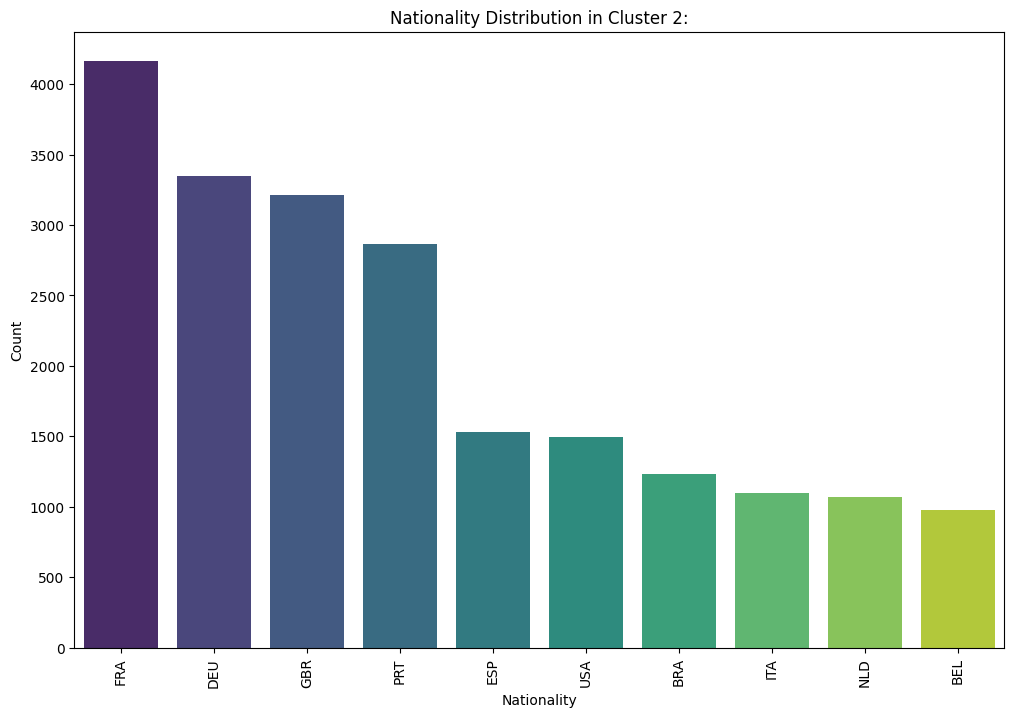

DistributionChannel
Travel Agent/Operator      28307
Electronic Distribution      303
Direct                        51
Name: count, dtype: int64
MarketSegment
Other                    20610
Travel Agent/Operator     4195
Groups                    3675
Direct                     107
Corporate                   71
Complementary                3
Name: count, dtype: int64


In [170]:
# Filter data for Cluster 2
# Count the occurrences of each nationality
cluster_2 = data[data['Cluster'] == 1]
nationality_counts = cluster_2['Nationality'].value_counts()

# Get the top 5 nationalities
top_5_nationalities = nationality_counts.head(5)

# Display the top 5 nationalities
print("Top 5 Nationalities in Cluster 2:")
print(top_5_nationalities)

top_10_nationalities = nationality_counts.head(10)
# Bar plot for nationality distribution in Cluster 2
plt.figure(figsize=(12, 8))
sns.barplot(x=top_10_nationalities.index, y=top_10_nationalities.values, palette='viridis')
plt.title('Nationality Distribution in Cluster 2:')
plt.xlabel('Nationality')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()

distributionChannel_counts = cluster_2['DistributionChannel'].value_counts()
marketSegment_counts = cluster_2['MarketSegment'].value_counts()
print(distributionChannel_counts)
print(marketSegment_counts)

Top 5 Nationalities in Cluster 3:
Nationality
FRA    6634
DEU    5929
PRT    4970
GBR    4342
ESP    2401
Name: count, dtype: int64


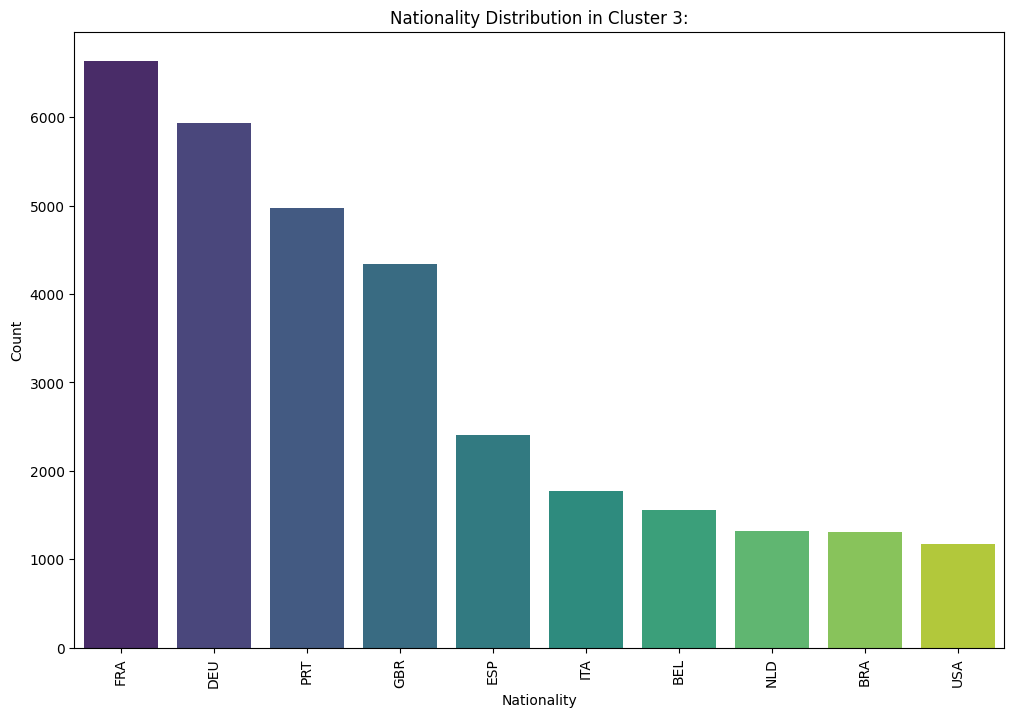

DistributionChannel
Travel Agent/Operator      39876
Direct                       702
Electronic Distribution      195
Corporate                    143
Name: count, dtype: int64
MarketSegment
Other                    27363
Travel Agent/Operator     7458
Groups                    5246
Direct                     735
Corporate                   96
Complementary               14
Aviation                     4
Name: count, dtype: int64


In [171]:
# Filter data for Cluster 3
# Count the occurrences of each nationality
cluster_3 = data[data['Cluster'] == 2]
nationality_counts = cluster_3['Nationality'].value_counts()

# Get the top 5 nationalities
top_5_nationalities = nationality_counts.head(5)

# Display the top 5 nationalities
print("Top 5 Nationalities in Cluster 3:")
print(top_5_nationalities)

top_10_nationalities = nationality_counts.head(10)
# Bar plot for nationality distribution in Cluster 3
plt.figure(figsize=(12, 8))
sns.barplot(x=top_10_nationalities.index, y=top_10_nationalities.values, palette='viridis')
plt.title('Nationality Distribution in Cluster 3:')
plt.xlabel('Nationality')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()

distributionChannel_counts = cluster_3['DistributionChannel'].value_counts()
marketSegment_counts = cluster_3['MarketSegment'].value_counts()
print(distributionChannel_counts)
print(marketSegment_counts)

